In [1]:
# interactive figure
%matplotlib widget

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cmocean
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import matplotlib.ticker as mtick
from dask_jobqueue import PBSCluster
from dask.distributed import LocalCluster, Client
from sys import platform
from xgcm import Grid
from viztool import pcolor_center, pcolor_limits, config_colorbar, create_register_cmaps, set_font
from mixdiag import interp_to_zi

In [3]:
if platform == 'linux' or platform == 'linux2':
    # data_dir = '/glade/derecho/scratch/zhihuaz/TracerInversion/Output/regular-res/'
    data_dir = '/glade/campaign/univ/umcp0020/zhihuaz/tracer-subduction/Lf1000/regular-res/'
elif platform == 'darwin':
    data_dir = '/Users/zhihua/Documents/Work/Research/Projects/TRACE-SEAS/TracerInversion/Data/'
else:
    print('OS not supported.')

create_register_cmaps()
set_font('Helvetica')

### Load data

In [4]:
cluster = LocalCluster(n_workers=16, threads_per_worker=1, memory_limit='14.5GB',
                       local_directory='/glade/derecho/scratch/zhihuaz/temp', dashboard_address=':8787')
client = Client(cluster)

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33271 instead
  warnings.warn(


In [5]:
cname0 = 'd11_M006_Ri020_em01_Q000_W000_D000_St0_surf-tracer'
cname1 = 'd11_M006_Ri020_em01_Q001_W000_D000_St0_surf-tracer'
cname3 = 'd11_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer'

periodic_coords = {dim : dict(left=f'{dim}F', center=f'{dim}C') for dim in 'xy'}
bounded_coords = {dim : dict(outer=f'{dim}F', center=f'{dim}C') for dim in 'z'}
coords = {dim : periodic_coords[dim] if tpl=='P' else bounded_coords[dim] for dim, tpl in zip('xyz', 'PPN')}

In [6]:
dsf0 = xr.open_mfdataset(data_dir + cname0 + '/hr*_GIfske_budget.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)
dsf0.close()

dsf1 = xr.open_mfdataset(data_dir + cname1 + '/hr*_GIfske_budget.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)
dsf1.close()

dsf3 = xr.open_mfdataset(data_dir + cname3 + '/hr*_GIfske_budget.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)
dsf3.close()

In [7]:
isubset_z_time = dict(zC=slice(5,None), zF=slice(5,None), time=slice(1,120,2))

ds0 = xr.open_dataset(data_dir+cname0+'_state.nc', decode_timedelta=False).isel(isubset_z_time).chunk(time=1)\
        .rename_vars({'c7': 'n', 'c8': 'c'})
ds0.close()
ds0['time'] = np.round(ds0.time)

ds1 = xr.open_dataset(data_dir+cname1+'_state.nc', decode_timedelta=False).isel(isubset_z_time).chunk(time=1)\
        .rename_vars({'c7': 'n', 'c8': 'c'})
ds1.close()
ds1['time'] = np.round(ds1.time)

ds3 = xr.open_dataset(data_dir+cname3+'_state.nc', decode_timedelta=False).isel(isubset_z_time).chunk(time=1)\
        .rename_vars({'c7': 'n', 'c8': 'c'})
ds3.close()
ds3['time'] = np.round(ds3.time)

In [8]:
depth_bmin = 70
bmin = np.floor((ds0.Lz - depth_bmin)*ds0.attrs['N₁²'] * 1e6) / 1e2
bsrf = np.floor(((depth_bmin - ds0.Hm)*ds0.attrs['N₁²'] + ds0.Hm*ds0.attrs['N₀²'] + ds0.Lf*ds0.attrs['M²']) * 1e6) / 1e2 + bmin

nlev = 30
delb0 = np.floor((bsrf - bmin)/nlev * 1e2) / 1e2
blines_upper = np.arange(bmin, bsrf, delb0)*1e-4

In [9]:
dsl0 = xr.open_mfdataset(data_dir + cname0 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1, xC=440, yC=220)
# dsl = xr.open_mfdataset(data_dir + cname + '/hr*_filtered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(zC=15)
dsl0.close()

dsl1 = xr.open_mfdataset(data_dir + cname1 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1, xC=440, yC=220)
dsl1.close()

dsl3 = xr.open_mfdataset(data_dir + cname3 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1, xC=440, yC=220)
dsl3.close()

In [10]:
def compute_diagnostics(ds, dsl, dsf, coords):
    dsl['u_c'] = dsl.u * dsl.c
    dsl['v_c'] = dsl.v * dsl.c
    dsl['w_c'] = dsl.w * dsl.c
    dsl['u_b'] = dsl.u * dsl.b
    dsl['v_b'] = dsl.v * dsl.b
    dsl['w_b'] = dsl.w * dsl.b

    dsf['IHSP'] = dsf['IHSP_δ'] + dsf['IHSP_σ']
    dsf['IVSP'] = dsf['IVSP_w'] + dsf['IVSP_uv']
    dsf['ISP']  = dsf['IHSP']   + dsf['IVSP']
    dsf['hour'] = (dsf.time - dsf.time[0])/3600 + 1

    dxF = dsl.xF.diff('xF').data[0]
    dyF = dsl.yF.diff('yF').data[0]
    dzF = dsl.zF.diff('zF').rename({'zF': 'zC'}).assign_coords(zC=dsl.zC).data
    grid = Grid(dsl, coords=coords)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bl_xf = grid.interp(dsl.b, axis='x').transpose(..., 'xF')
        bl_yf = grid.interp(dsl.b, axis='y').transpose(..., 'yF')
        bl_zf = grid.interp(dsl.b, axis='z', boundary='extend').transpose(..., 'zF')

        cl_xf = grid.interp(dsl.c, axis='x').transpose(..., 'xF')
        cl_yf = grid.interp(dsl.c, axis='y').transpose(..., 'yF')
        cl_zf = grid.interp(dsl.c, axis='z', boundary='extend').transpose(..., 'zF')

        ul_xf = grid.interp(dsl.u, axis='x').transpose(..., 'xF')
        ul_yf = grid.interp(dsl.u, axis='y').transpose(..., 'yF')
        ul_zf = grid.interp(dsl.u, axis='z', boundary='extend').transpose(..., 'zF')

        vl_xf = grid.interp(dsl.v, axis='x').transpose(..., 'xF')
        vl_yf = grid.interp(dsl.v, axis='y').transpose(..., 'yF')
        vl_zf = grid.interp(dsl.v, axis='z', boundary='extend').transpose(..., 'zF')

        wl_xf = grid.interp(dsl.w, axis='x').transpose(..., 'xF')
        wl_yf = grid.interp(dsl.w, axis='y').transpose(..., 'yF')

        dsl['dbdx'] = grid.diff(bl_xf, axis='x') / dxF
        dsl['dbdy'] = grid.diff(bl_yf, axis='y') / dyF
        dsl['dbdz'] = grid.diff(bl_zf, axis='z') / dzF

        dsl['dcdx'] = grid.diff(cl_xf, axis='x') / dxF
        dsl['dcdy'] = grid.diff(cl_yf, axis='y') / dyF
        dsl['dcdz'] = grid.diff(cl_zf, axis='z') / dzF

        dsl['dudx'] = grid.diff(ul_xf, axis='x') / dxF
        dsl['dudy'] = grid.diff(ul_yf, axis='y') / dyF
        dsl['dudz'] = grid.diff(ul_zf, axis='z') / dzF

        dsl['dvdx'] = grid.diff(vl_xf, axis='x') / dxF
        dsl['dvdy'] = grid.diff(vl_yf, axis='y') / dyF
        dsl['dvdz'] = grid.diff(vl_zf, axis='z') / dzF

        dsl['dwdx'] = grid.diff(wl_xf, axis='x') / dxF
        dsl['dwdy'] = grid.diff(wl_yf, axis='y') / dyF

    dsl['mGb']  = np.sqrt(dsl.dbdx**2 + dsl.dbdy**2 + dsl.dbdz**2)
    dsl['nGbx'] = dsl.dbdx / dsl.mGb
    dsl['nGby'] = dsl.dbdy / dsl.mGb
    dsl['nGbz'] = dsl.dbdz / dsl.mGb
    
    dsl['FFc_dia'] = dsl.uc * dsl.nGbx + dsl.vc * dsl.nGby + dsl.wc * dsl.nGbz
    dsl['wc_dia']  = (dsl.FFc_dia * dsl.nGbz)#.where(dsl.mGb >= 1e-8)
    dsl['wc_iso']  = dsl.wc - dsl.wc_dia

    dsl['SFc_dia'] = dsl.u_c * dsl.nGbx + dsl.v_c * dsl.nGby + dsl.w_c * dsl.nGbz
    dsl['w_c_dia'] = (dsl.SFc_dia * dsl.nGbz)#.where(dsl.mGb >= 1e-8)
    dsl['w_c_iso'] = dsl.w_c - dsl.w_c_dia

    # dsl['mGc']  = np.sqrt(dsl.dcdx**2 + dsl.dcdy**2 + dsl.dcdz**2)
    # dsl['nGcx'] = dsl.dcdx / dsl.mGc
    # dsl['nGcy'] = dsl.dcdy / dsl.mGc
    # dsl['nGcz'] = dsl.dcdz / dsl.mGc

    dsl['δ']  = dsl.dudx + dsl.dvdy
    dsl['σₙ'] = dsl.dudx - dsl.dvdy
    dsl['σₛ'] = dsl.dvdx + dsl.dudy
    dsl['ζ']  = dsl.dvdx - dsl.dudy
    dsl['σ']  = np.sqrt(dsl['σₙ']**2 + dsl['σₛ']**2)
    dsl['M²'] = np.sqrt(dsl['dbdx']**2 + dsl['dbdy']**2)
    return ds, dsl, dsf

In [11]:
ds0, dsl0, dsf0 = compute_diagnostics(ds0, dsl0, dsf0, coords)
ds1, dsl1, dsf1 = compute_diagnostics(ds1, dsl1, dsf1, coords)
ds3, dsl3, dsf3 = compute_diagnostics(ds3, dsl3, dsf3, coords)

### Snapshots of decomposition

In [ ]:
dsl = dsl1.copy()
dsf = dsf1.copy()

itime = 31 - 1
mask = (dsl.is_fz == 1).compute()
dsf.mld.where(mask).isel(time=itime).mean(['xC', 'yC']).compute()

In [ ]:
zi_to_mld = 1
mag = 1.75e-4

# wc_mld     = interp_to_zi(dsl.wc.isel(time=itime),     -dsf.mld.isel(time=itime)*zi_to_mld)
# wc_mld_dia = interp_to_zi(dsl.wc_dia.isel(time=itime), -dsf.mld.isel(time=itime)*zi_to_mld)
# wc_mld_iso = interp_to_zi(dsl.wc_iso.isel(time=itime), -dsf.mld.isel(time=itime)*zi_to_mld)
# wc_mld_rd  = wc_mld_dia / wc_mld.where(np.abs(wc_mld) > mag/10)

depth = 17
wc_mld     = dsl.wc.isel(time=itime).sel(zC=-depth, method='nearest')
wc_mld_dia = dsl.wc_dia.isel(time=itime).sel(zC=-depth, method='nearest')
wc_mld_iso = dsl.wc_iso.isel(time=itime).sel(zC=-depth, method='nearest')
wc_mld_rd  = wc_mld_dia / wc_mld.where(np.abs(wc_mld) > mag/10)

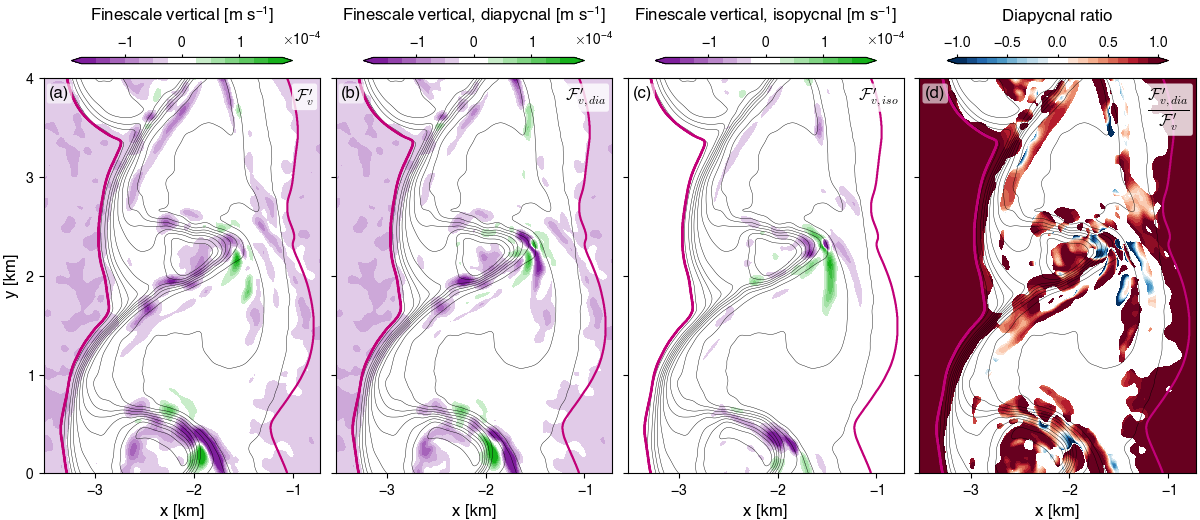

In [42]:
plt.close()
_,ax = plt.subplots(1,4, figsize=(12, 5.2), constrained_layout=True, sharex=True, sharey=True)

pcm0,_ = pcolor_center(wc_mld,     ax[0], cmap=plt.get_cmap('cp_ds',14), smag=mag)
pcm1,_ = pcolor_center(wc_mld_dia, ax[1], cmap=plt.get_cmap('cp_ds',14), smag=mag)
pcm2,_ = pcolor_center(wc_mld_iso, ax[2], cmap=plt.get_cmap('cp_ds',14), smag=mag)
pcm3,_ = pcolor_center(wc_mld_rd,  ax[3], cmap=plt.get_cmap('RdBu_r_ds',20), smag=1)

cbar = config_colorbar(pcm0, ax=ax[0], sci_notation=True, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale vertical [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm1, ax=ax[1], sci_notation=True, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale vertical, diapycnal [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm2, ax=ax[2], sci_notation=True, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale vertical, isopycnal [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm3, ax=ax[3], sci_notation=True, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Diapycnal ratio', size=12, labelpad=10)

txt_str = 'abcd'
lgd_str = [r'$\mathcal{F}^{\,\prime}_v$',#|_{z_s}$',
           r'$\mathcal{F}^{\,\prime}_{v,dia}$',#|_{z_s}$',
           r'$\mathcal{F}^{\,\prime}_{v,iso}$',#|_{z_s}$',
           r'$\dfrac{ \mathcal{F}^{\,\prime}_{v,dia} }{ \mathcal{F}^{\,\prime}_v }$']

for j in range(4):
    ax[j].text(0.02, 0.98, f'({txt_str[j]})', fontsize=12, ha='left',  va='top', transform=ax[j].transAxes,
               bbox=dict(facecolor='w', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.15'))
    ax[j].contour(dsl.xC/1e3, dsl.yC/1e3, dsl.b.isel(time=itime).isel(zC=-1), blines_upper, colors='k', linewidths=0.3)
    ax[j].text(0.98, 0.98, lgd_str[j], ha='right', va='top', transform=ax[j].transAxes, fontsize=12,
               bbox=dict(facecolor='w', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.15'))
    ax[j].contour(dsl.xC/1e3, dsl.yC/1e3, dsl['is_fz'].isel(time=itime), [0.5, 1.5], colors='xkcd:magenta', linewidths=1.5)
    ax[j].set_aspect('equal')
    ax[j].set_xlabel(r'x [km]', fontsize=12)
ax[0].set_yticks(np.linspace(0,4,5))
ax[0].set_xticks(np.linspace(-4,4,9))
ax[0].set_xlim(-3.52, -0.72)
ax[0].set_ylabel(r'y [km]', fontsize=12);

In [43]:
plt.savefig(f'../Figures/{cname1}_flux_decomp_map.png', dpi=900);

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


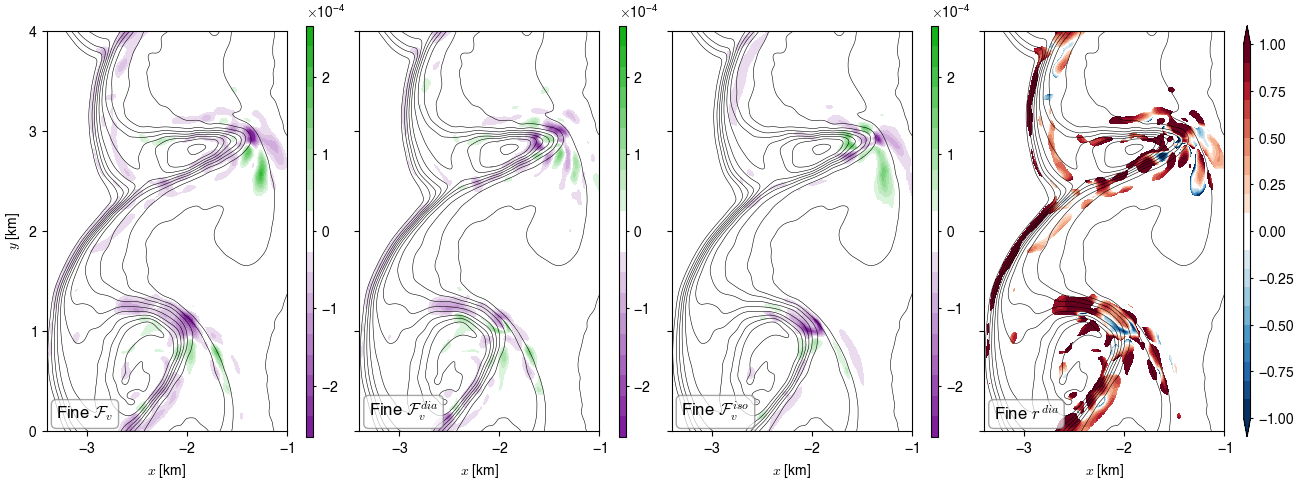

In [23]:
plt.close()
_,ax = plt.subplots(1,4, figsize=(13, 4.8), constrained_layout=True, sharex=True, sharey=True)

pcm0,mag0 = pcolor_center(wc_mld, ax[0], cmap=plt.get_cmap('cp_ds',20), cupr=2.5)
pcm1,_    = pcolor_center(wc_mld_dia, ax[1], cmap=plt.get_cmap('cp_ds',20), smag=mag0)
pcm2,_    = pcolor_center(wc_mld_iso, ax[2], cmap=plt.get_cmap('cp_ds',20), smag=mag0)
pcm3,_    = pcolor_center(wc_mld_dia/wc_mld.where(np.abs(wc_mld) >= mag0/10), 
                          ax[3], cmap=plt.get_cmap('RdBu_r_ds',20), smag=1)

config_colorbar(pcm0, ax[0])
config_colorbar(pcm1, ax[1])
config_colorbar(pcm2, ax[2])
config_colorbar(pcm3, ax[3], extend='both')

txt_strs = [r"Fine $\mathcal{F}_v$", r"Fine $\mathcal{F}_v^{\,dia}$", r"Fine $\mathcal{F}_v^{\,iso}$", r"Fine $r^{\,dia}$"]
for j in range(4):
    ax[j].contour(ds_parent.xC/1e3, ds_parent.yC/1e3, ds_parent.b.isel(time=itime, zC=-1),
                  blines_upper, colors='k', linewidths=0.4)
    ax[j].text(0.04, 0.02, txt_strs[j], ha='left', va='bottom', transform=ax[j].transAxes, fontsize=12,# fontweight='bold',
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.7, boxstyle='round,pad=0.3'))
    ax[j].set_aspect('equal')
    ax[j].set_xlabel(r'$x$ [km]')
ax[0].set_yticks(np.linspace(0,4,5))
ax[0].set_xticks(np.linspace(-4,4,9))
ax[0].set_xlim(-3.4, -1)
# ax[0].set_xlim(1, 3)
ax[0].set_ylabel(r'$y$ [km]');

### Mean profiles of decomposition

In [12]:
dsl = [dsl1.sel(xC=slice(None, 0)), dsl3.sel(xC=slice(None, 0))]
dsf = [dsf1.sel(xC=slice(None, 0)), dsf3.sel(xC=slice(None, 0))]
itime = slice(14 - 1, 48 - 1)

mean_mld = []
mean_mldnf = []
mean_c = []
mean_cnf = []
mean_wc = []
mean_wcnf = []
mean_wc_dia = []
mean_w_c = []
mean_w_c_dia = []

for j in range(2):
    mask   = (dsl[j].is_fz == 1).compute()
    masknf = np.abs(dsl[j].xC) >= 3600

    mean_mld.append( dsf[j].mld.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_mldnf.append( dsf[j].mld.where(masknf).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_c.append( dsl[j].c.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_cnf.append( dsl[j].c.where(masknf).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_wc.append( dsl[j].wc.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_wcnf.append( dsl[j].wc.where(masknf).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_wc_dia.append( dsl[j].wc_dia.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_w_c.append( dsl[j].w_c.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )
    mean_w_c_dia.append( dsl[j].w_c_dia.where(mask).isel(time=itime).mean(['xC', 'yC']).compute() )

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large gr

In [13]:
mean_dcdz = []
mean_dcdznf = []

grid = Grid(dsl[0].isel(time=itime), coords=coords)
dzF = dsl[0].zF.diff('zF').rename({'zF': 'zC'}).assign_coords(zC=dsl[0].zC).data
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j in range(2):
        mc   = xr.where(mean_c[j]>=1e-9,   mean_c[j],   0)
        mcnf = xr.where(mean_cnf[j]>=1e-9, mean_cnf[j], 0)
        mc_zf   = grid.interp(mc,   axis='z', boundary='extend').transpose(..., 'zF')
        mcnf_zf = grid.interp(mcnf, axis='z', boundary='extend').transpose(..., 'zF')
        mean_dcdz.append( (grid.diff(mc_zf, axis='z') / dzF).compute() )
        mean_dcdznf.append( (grid.diff(mcnf_zf, axis='z') / dzF).compute() )

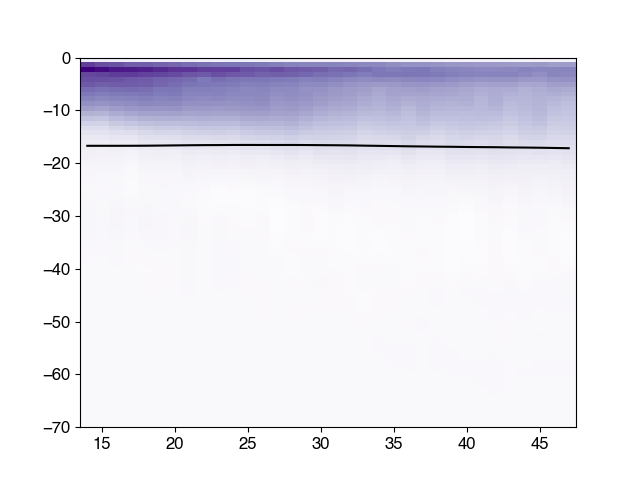

In [14]:
plt.close()
plt.figure()

plt.pcolormesh(dsf1.hour.isel(time=itime), dsl1.zC, mean_wc_dia[0].T, cmap='Purples_r')
plt.plot(dsf1.hour.isel(time=itime), -mean_mld[0], 'k')
plt.ylim(-70, 0);

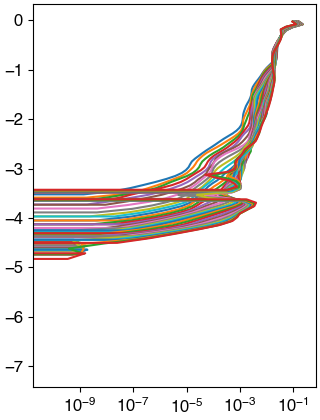

In [15]:
plt.close()
plt.figure(figsize=(3.2,4.2), constrained_layout=True)
# plt.plot(Kcnf[0].T / (dsl[0].attrs['B₀']**(1/3) * mean_mldnf[0]**(4/3)), dsl[0].zC / mean_mldnf[0], 'gray')
# plt.plot(Kcnf[1].T / (dsl[1].attrs['B₀']**(1/3) * mean_mldnf[1]**(4/3)), dsl[1].zC / mean_mldnf[1], 'k')
# plt.plot(Kc[0].T / (dsl[0].attrs['B₀']**(1/3) * mean_mld[0]**(4/3)), dsl[0].zC / mean_mld[0], 'C0')
# plt.plot(Kc[1].T / (dsl[1].attrs['B₀']**(1/3) * mean_mld[1]**(4/3)), dsl[1].zC / mean_mld[1], 'C1')
plt.plot(mean_dcdz[0].T, dsl[0].zC / mean_mld[0]);
# plt.xlim(0, 0.4)
# plt.ylim(-1.5, -0);
plt.xscale('log')

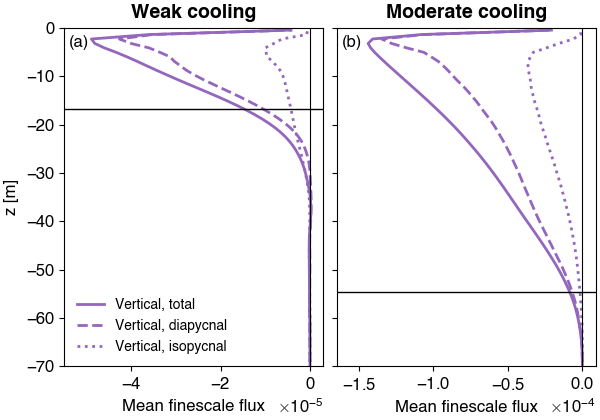

In [16]:
plt.close()
_,ax = plt.subplots(1,2, figsize=(6,4.2), constrained_layout=True, sharey=True)#, sharex='col')

case_str = ['Weak cooling', 'Moderate cooling']
txt_str = 'ab'

for j in range(2):
    # ax[j].plot(mean_wcnf[j].mean('time'),   dsl[j].zC, lw=2, c='#969696')
    ax[j].plot(mean_wc[j].mean('time'),     dsl[j].zC, lw=2, c='C4')
    ax[j].plot(mean_wc_dia[j].mean('time'), dsl[j].zC, lw=2, c='C4', ls='--')
    ax[j].plot((mean_wc[j] - mean_wc_dia[j]).mean('time'), dsl[j].zC, lw=2, c='C4', ls=':')
    ax[j].axhline(-mean_mld[j].mean('time'), ls='-', c='k', lw=1)
    ax[j].set_title(case_str[j], fontsize=14, fontweight='bold')
    ax[j].text(0.02, 0.98, f'({txt_str[j]})', fontsize=12, ha='left',  va='top', transform=ax[j].transAxes)
    ax[j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax[j].axvline(0, ls='-', c='k', lw=0.8)
ax[0].legend(['Vertical, total', 'Vertical, diapycnal', 'Vertical, isopycnal'], frameon=False, fontsize=10, handlelength=2)
ax[0].set_ylabel(r'z [m]', fontsize=12)
ax[0].set_xlabel(r'Mean finescale flux', fontsize=12)
ax[1].set_xlabel(r'Mean finescale flux', fontsize=12)

ax[0].set_ylim(-70, 0)
ax[0].set_xlim(-5.5e-5,  3e-6)
ax[1].set_xlim(-16.5e-5, 9e-6);

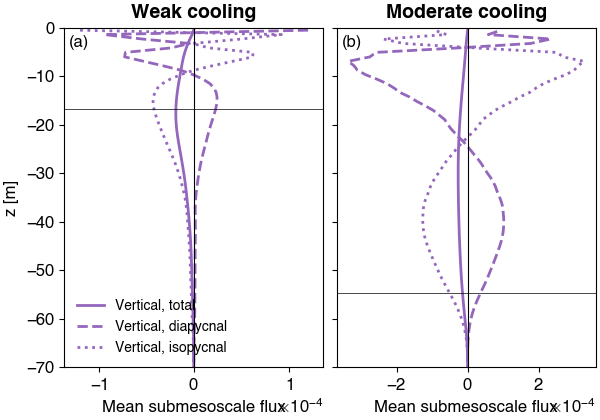

In [17]:
plt.close()
_,ax = plt.subplots(1,2, figsize=(6,4.2), constrained_layout=True, sharey=True)#, sharex='col')

case_str = ['Weak cooling', 'Moderate cooling']
txt_str = 'ab'

for j in range(2):
    ax[j].plot(mean_w_c[j].mean('time'),     dsl[j].zC, lw=2, c='C4')
    ax[j].plot(mean_w_c_dia[j].mean('time'), dsl[j].zC, lw=2, c='C4', ls='--')
    ax[j].plot((mean_w_c[j] - mean_w_c_dia[j]).mean('time'), dsl[j].zC, lw=2, c='C4', ls=':')
    ax[j].axhline(-mean_mld[j].mean('time'), ls='-', c='k', lw=0.5)
    ax[j].set_title(case_str[j], fontsize=14, fontweight='bold')
    ax[j].text(0.02, 0.98, f'({txt_str[j]})', fontsize=12, ha='left',  va='top', transform=ax[j].transAxes)
    ax[j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax[j].axvline(0, ls='-', c='k', lw=0.8)
ax[0].legend(['Vertical, total', 'Vertical, diapycnal', 'Vertical, isopycnal'], frameon=False, fontsize=10, loc='lower left')
ax[0].set_ylabel(r'z [m]', fontsize=12)
ax[0].set_xlabel(r'Mean submesoscale flux', fontsize=12)
ax[1].set_xlabel(r'Mean submesoscale flux', fontsize=12)

ax[0].set_ylim(-70, 0);
# ax[0].set_xlim(-5.5e-5,  3e-6)
# ax[1].set_xlim(-16.5e-5, 9e-6);

In [18]:
def get_K_on_sigma(wc, dcdz, z, H, sigma, B0):
    K_on_z = -wc / dcdz
    nt = H.size
    nz = sigma.size
    K_on_zoH = np.zeros((nz, nt))
    wstar = (B0*H)**(1/3)
    for j in range(nt):
        K_on_zoH[:,j] = np.interp(sigma, z/H[j], K_on_z[j,:])
    return K_on_zoH / (wstar * H).data

In [19]:
Kc = []
Kcnf = []
Kc_dia = []
sigma = np.arange(-2, 0, 0.02)

for j in range(2):
    Kcnf.append( get_K_on_sigma(mean_wcnf[j], mean_dcdznf[j], dsl[j].zC, mean_mldnf[j], sigma, dsl[j].attrs['B₀']) )
    Kc.append( get_K_on_sigma(mean_wc[j], mean_dcdz[j], dsl[j].zC, mean_mld[j], sigma, dsl[j].attrs['B₀']) )
    Kc_dia.append( get_K_on_sigma(mean_wc_dia[j], mean_dcdz[j], dsl[j].zC, mean_mld[j], sigma, dsl[j].attrs['B₀']) )

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


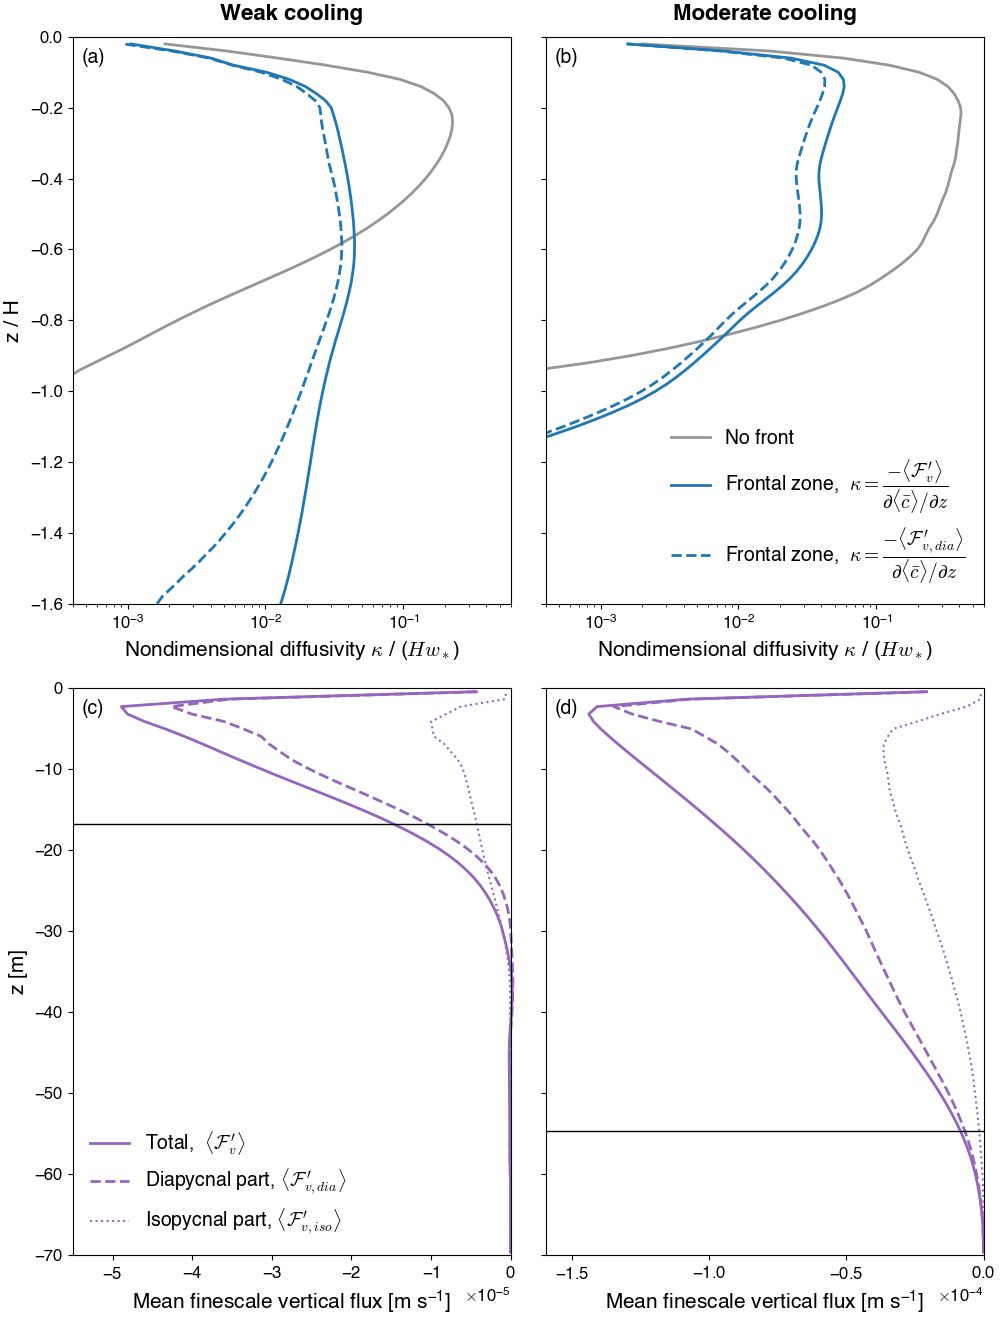

In [20]:
plt.close()
_,ax = plt.subplots(2,2, figsize=(10,13.2), constrained_layout=True, sharey='row',
                    gridspec_kw={'wspace': 0.05, 'hspace': 0.03})

case_str = ['Weak cooling', 'Moderate cooling']
txt_str = 'abcd'
count = 0

for j in range(2):
    ax[0,j].plot(Kcnf[j].mean(axis=1),   sigma, lw=2, c='#969696')
    ax[0,j].plot(Kc[j].mean(axis=1),     sigma, lw=2, c='C0')
    ax[0,j].plot(Kc_dia[j].mean(axis=1), sigma, lw=2, c='C0', ls='--')
    ax[0,j].axvline(0, ls='-', c='k', lw=0.8)
    ax[0,j].set_title(case_str[j], fontsize=16, fontweight='bold', pad=12)
    ax[0,j].text(0.02, 0.98, f'({txt_str[count]})', fontsize=14, ha='left', va='top', transform=ax[0,j].transAxes)
    count += 1
ax[0,0].set_ylim(-1.6, -0);
ax[0,0].set_xlim(4e-4, 6e-1)
ax[0,1].set_xlim(4e-4, 6e-1)
ax[0,0].set_xscale('log')
ax[0,1].set_xscale('log')
ax[0,1].legend(['No front',
                r'Frontal zone,  $\kappa = \dfrac{ -\langle \mathcal{F}^{\,\prime}_v  \rangle }{ \partial \langle \bar{c} \rangle / \partial z}$',
                r'Frontal zone,  $\kappa = \dfrac{ -\langle \mathcal{F}^{\,\prime}_{v,dia} \rangle }{ \partial \langle \bar{c} \rangle / \partial z}$',
               ], frameon=False, fontsize=14, loc='lower right')
ax[0,0].set_ylabel(r'z / H', fontsize=15);
ax[0,0].set_xlabel(r'Nondimensional diffusivity $\kappa$ / ($H w_* $)', fontsize=15)
ax[0,1].set_xlabel(r'Nondimensional diffusivity $\kappa$ / ($H w_* $)', fontsize=15);


for j in range(2):
    ax[1,j].plot(mean_wc[j].mean('time').sel(zC=slice(-70,0)),     dsl[j].zC.sel(zC=slice(-70,0)), lw=2, c='C4', clip_on=False)
    ax[1,j].plot(mean_wc_dia[j].mean('time').sel(zC=slice(-70,0)), dsl[j].zC.sel(zC=slice(-70,0)), lw=2, c='C4', ls='--', clip_on=False)
    ax[1,j].plot((mean_wc[j] - mean_wc_dia[j]).mean('time').sel(zC=slice(-70,0)), dsl[j].zC.sel(zC=slice(-70,0)), lw=1.5, c='C4', ls=':', clip_on=False)
    ax[1,j].axhline(-mean_mld[j].mean('time'), ls='-', c='k', lw=1)
    ax[1,j].text(0.02, 0.98, f'({txt_str[count]})', fontsize=14, ha='left',  va='top', transform=ax[1,j].transAxes)
    ax[1,j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    # ax[1,j].axvline(0, ls='-', c='k', lw=0.8)
    count += 1
ax[1,0].legend([r'Total,  $\langle \mathcal{F}^{\,\prime}_v \rangle$',
                r'Diapycnal part, $\langle \mathcal{F}^{\,\prime}_{v,dia} \rangle$',
                r'Isopycnal part, $\langle \mathcal{F}^{\,\prime}_{v,iso} \rangle$'], frameon=False, fontsize=14)
ax[1,0].set_ylabel(r'z [m]', fontsize=15)
ax[1,0].set_xlabel(r'Mean finescale vertical flux [m s$\mathregular{^{-1}}$]', fontsize=15)
ax[1,1].set_xlabel(r'Mean finescale vertical flux [m s$\mathregular{^{-1}}$]', fontsize=15)
ax[1,1].xaxis.set_major_locator(mtick.MultipleLocator(5e-5))
ax[1,0].set_ylim(-70, 0)
ax[1,0].set_xlim(-5.5e-5,  0)#2e-6)
ax[1,1].set_xlim(-15.95e-5, 0);#5.8e-6);

plt.savefig(f'../Figures/flux_decomp_kappa.png', dpi=300);

### Mean profiles

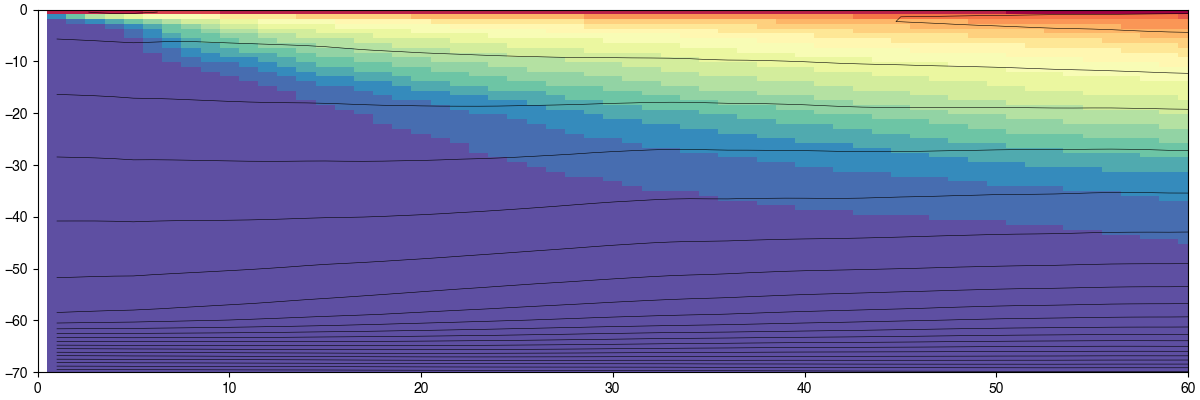

In [43]:
plt.close()
_,ax = plt.subplots(1,1, figsize=(12,4), constrained_layout=True, sharey=True)#, sharex='col')

# mask = np.abs(dsl1.xC) >= 3600
mask = (dsl1['M²'].sel(zC=slice(-60, 0)).mean('zC') >= 1e-8)

clm = dsl1.c.where(mask).mean(['xC', 'yC'])
blm = dsl1.b.where(mask).mean(['xC', 'yC'])

plt.pcolormesh(dsf1.hour, dsl1.zC, clm.T, cmap=plt.get_cmap('Spectral_r',20), vmin=0, vmax=1)
plt.contour(dsf1.hour, dsl1.zC, blm.T, blines_upper, colors='k', linewidths=0.4)
plt.ylim(-70, 0)
plt.xlim(0, 60);

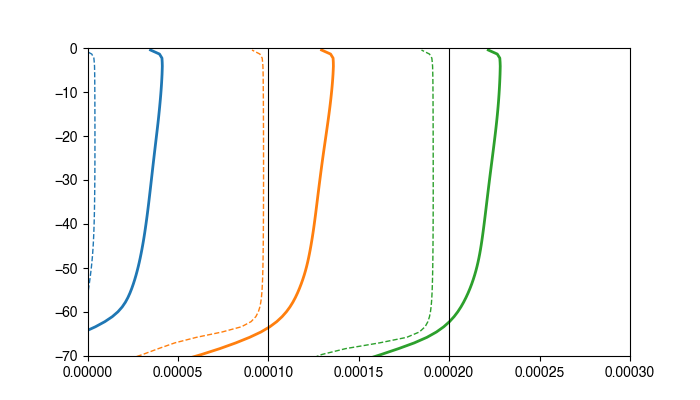

In [21]:
plt.close()
_,ax = plt.subplots(1,1, figsize=(7,4))

dsl = dsl3.copy()

mask = (dsl['M²'].sel(zC=slice(-60, 0)).mean('zC') >= 1e-8)#.compute()
blm = dsl.b.where(mask).mean(['xC', 'yC'])-6.5e-4
plt.plot(blm.isel(time=20-1),   dsl.zC, lw=2)
plt.plot(blm.isel(time=40-1)+1e-4, dsl.zC, lw=2)
plt.plot(blm.isel(time=60-1)+2e-4, dsl.zC, lw=2)

ax.set_prop_cycle(None)

mask = np.abs(dsl.xC) >= 3600
blm = dsl.b.where(mask).mean(['xC', 'yC'])-6.5e-4
plt.plot(blm.isel(time=20-1),   dsl.zC, lw=1, ls='--')
plt.plot(blm.isel(time=40-1)+1e-4, dsl.zC, lw=1, ls='--')
plt.plot(blm.isel(time=60-1)+2e-4, dsl.zC, lw=1, ls='--')

plt.axvline(1e-4, c='k', lw=0.8)
plt.axvline(2e-4, c='k', lw=0.8)
plt.ylim(-70, 0)
plt.xlim(0, 3e-4);

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large gr

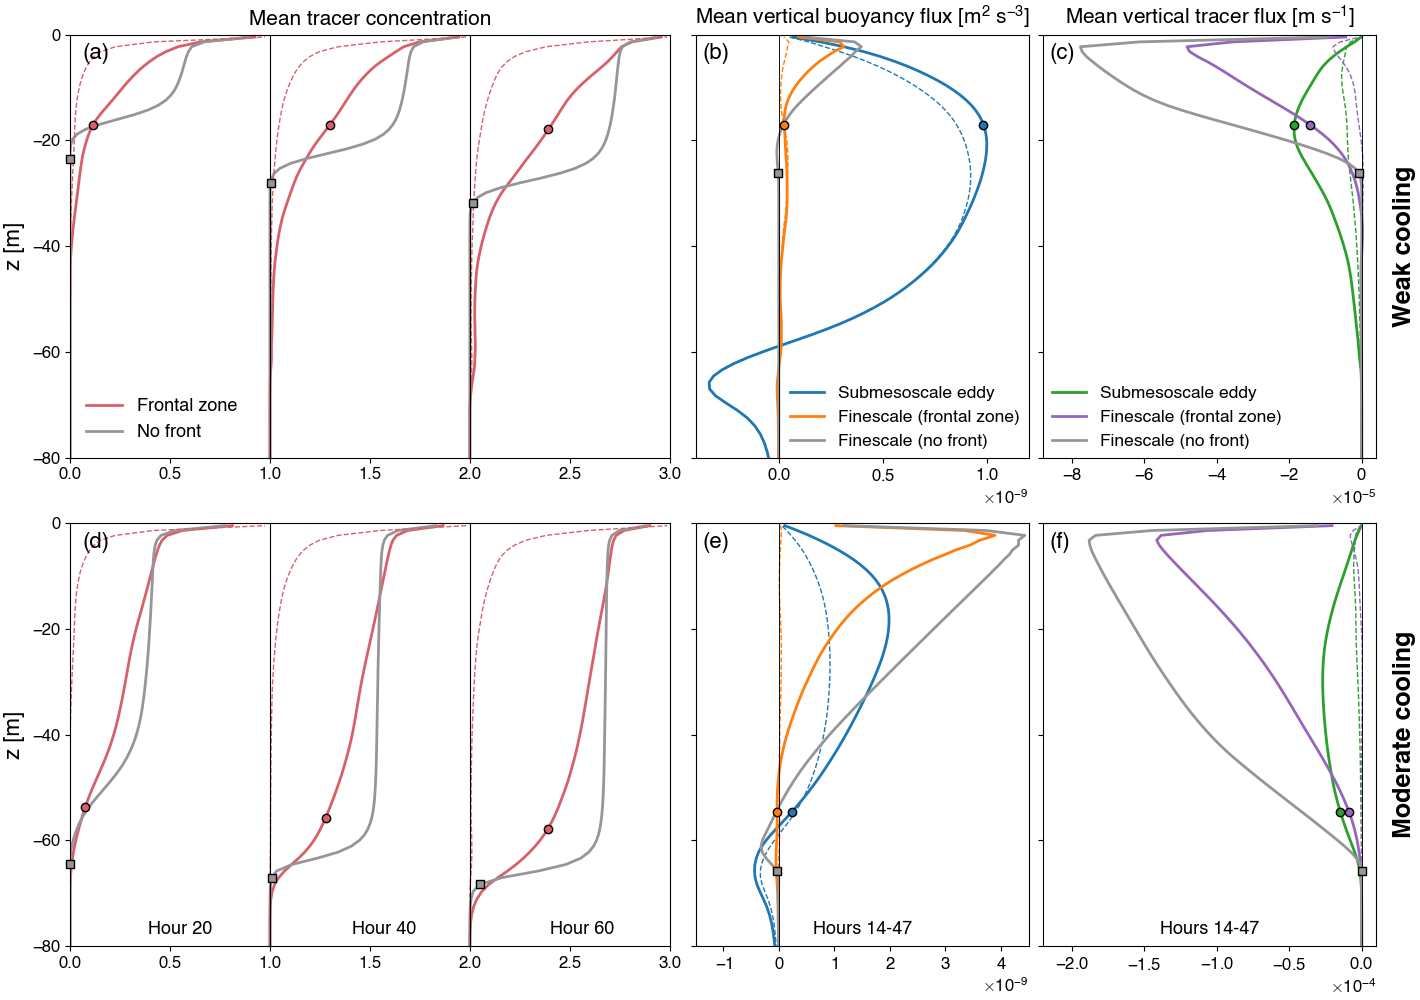

In [22]:
plt.close()
_,ax = plt.subplots(2,3, figsize=(14.2,10), width_ratios=[1.8, 1, 1], constrained_layout=True, sharey=True)#, sharex='col')

dsl = [dsl1.sel(xC=slice(None, 0)), dsl3.sel(xC=slice(None, 0))]
dsf = [dsf1.sel(xC=slice(None, 0)), dsf3.sel(xC=slice(None, 0))]
itime = slice(14 - 1, 48 - 1)

case_str = ['Weak cooling', 'Moderate cooling']
txt_str = 'abcdef'
count = 0

dsl0l = dsl0.sel(xC=slice(None, 0))
mask0 = (dsl0l.is_fz == 1).compute()
wl = dsl0l.w.where(mask0)
bl = dsl0l.b.where(mask0)
cl = dsl0l.c.where(mask0)

clm0 = cl.mean(['xC', 'yC'])
mean_w_b0 = (wl * (bl - bl.mean(['xC', 'yC']))).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
mean_wb0  = dsl0l.wb.where(mask0).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
mean_w_c0 = (wl * (cl - cl.mean(['xC', 'yC']))).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
mean_wc0  = dsl0l.wc.where(mask0).isel(time=itime).mean(['xC', 'yC', 'time']).compute()

for i in range(2):
    mask    = (dsl[i].is_fz == 1).compute()
    mask_nf = np.abs(dsl[i].xC) >= 3600
    mld     = dsf[i].mld.where(mask)
    mld_nf  = dsf[i].mld.where(mask_nf)
    
    wl = dsl[i].w.where(mask)
    bl = dsl[i].b.where(mask)
    cl = dsl[i].c.where(mask)

    clm = cl.mean(['xC', 'yC'])
    clm_nf = dsl[i].c.where(mask_nf).mean(['xC', 'yC'])

    mean_mld    = mld.isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    mean_mld_nf = mld_nf.isel(time=itime).mean(['xC', 'yC', 'time']).compute()

    mean_w_b   = (wl * (bl - bl.mean(['xC', 'yC']))).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    # mean_w_b   = dsl[i].w_b.where(mask).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    mean_wb    = dsl[i].wb.where(mask).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    mean_wb_nf = dsl[i].wb.where(mask_nf).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    
    mean_w_c   = (wl * (cl - cl.mean(['xC', 'yC']))).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    # mean_w_c   = dsl[i].w_c.where(mask).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    mean_wc    = dsl[i].wc.where(mask).isel(time=itime).mean(['xC', 'yC', 'time']).compute()
    mean_wc_nf = dsl[i].wc.where(mask_nf).isel(time=itime).mean(['xC', 'yC', 'time']).compute()

    ax[i,0].plot(clm.isel(time=20-1),      dsl[i].zC, lw=2, c='#d6616b')
    ax[i,0].plot(clm.isel(time=40-1)+1,    dsl[i].zC, lw=2, c='#d6616b', label='_nolegend_')
    ax[i,0].plot(clm.isel(time=60-1)+2,    dsl[i].zC, lw=2, c='#d6616b', label='_nolegend_')
    ax[i,0].plot(clm_nf.isel(time=20-1),   dsl[i].zC, lw=2, c='#969696')
    ax[i,0].plot(clm_nf.isel(time=40-1)+1, dsl[i].zC, lw=2, c='#969696')
    ax[i,0].plot(clm_nf.isel(time=60-1)+2, dsl[i].zC, lw=2, c='#969696')
    ax[i,0].plot(clm0.isel(time=20-1),   dsl0.zC, lw=1, c='#d6616b', ls='--')
    ax[i,0].plot(clm0.isel(time=40-1)+1, dsl0.zC, lw=1, c='#d6616b', ls='--')
    ax[i,0].plot(clm0.isel(time=60-1)+2, dsl0.zC, lw=1, c='#d6616b', ls='--')
    ax[i,0].axvline(1, c='k', lw=0.8)
    ax[i,0].axvline(2, c='k', lw=0.8)
    mld20 = mld.isel(time=20-1).mean(['xC', 'yC']).compute()
    mld40 = mld.isel(time=40-1).mean(['xC', 'yC']).compute()
    mld60 = mld.isel(time=60-1).mean(['xC', 'yC']).compute()
    ax[i,0].plot(clm.isel(time=20-1).sel(zC=-mld20, method='nearest'), 
                 dsl[i].zC.sel(zC=-mld20, method='nearest'), 'o', mec='k', c='#d6616b', ms=6, label='_nolegend_')
    ax[i,0].plot(clm.isel(time=40-1).sel(zC=-mld40, method='nearest')+1, 
                 dsl[i].zC.sel(zC=-mld40, method='nearest'), 'o', mec='k', c='#d6616b', ms=6, label='_nolegend_')
    ax[i,0].plot(clm.isel(time=60-1).sel(zC=-mld60, method='nearest')+2, 
                 dsl[i].zC.sel(zC=-mld60, method='nearest'), 'o', mec='k', c='#d6616b', ms=6, label='_nolegend_')
    mld20_nf = mld_nf.isel(time=20-1).mean(['xC', 'yC']).compute()
    mld40_nf = mld_nf.isel(time=40-1).mean(['xC', 'yC']).compute()
    mld60_nf = mld_nf.isel(time=60-1).mean(['xC', 'yC']).compute()
    ax[i,0].plot(clm_nf.isel(time=20-1).sel(zC=-mld20_nf, method='nearest'), 
                 dsl[i].zC.sel(zC=-mld20_nf, method='nearest'), 's', mec='k', c='#969696', ms=6, label='_nolegend_', clip_on=False, zorder=3)
    ax[i,0].plot(clm_nf.isel(time=40-1).sel(zC=-mld40_nf, method='nearest')+1, 
                 dsl[i].zC.sel(zC=-mld40_nf, method='nearest'), 's', mec='k', c='#969696', ms=6, label='_nolegend_')
    ax[i,0].plot(clm_nf.isel(time=60-1).sel(zC=-mld60_nf, method='nearest')+2, 
                 dsl[i].zC.sel(zC=-mld60_nf, method='nearest'), 's', mec='k', c='#969696', ms=6, label='_nolegend_')

    ax[i,1].plot(mean_w_b,  dsl[i].zC, lw=2, c='C0')
    ax[i,1].plot(mean_w_b0, dsl[i].zC, lw=1, c='C0', ls='--', label='_nolegend_')
    ax[i,1].plot(mean_wb,   dsl[i].zC, lw=2, c='C1')
    ax[i,1].plot(mean_wb0,  dsl[i].zC, lw=1, c='C1', ls='--', label='_nolegend_')
    ax[i,1].plot(mean_wb_nf, dsl[i].zC, lw=2, c='#969696')
    ax[i,1].plot(mean_w_b.sel(zC=-mean_mld, method='nearest'), 
                 dsl[i].zC.sel(zC=-mean_mld, method='nearest'), 'o', mec='k', c='C0', ms=6, label='_nolegend_')
    ax[i,1].plot(mean_wb.sel(zC=-mean_mld, method='nearest'),  
                 dsl[i].zC.sel(zC=-mean_mld, method='nearest'), 'o', mec='k', c='C1', ms=6, label='_nolegend_', zorder=3)
    ax[i,1].plot(mean_wb_nf.sel(zC=-mean_mld_nf, method='nearest'), 
                 dsl[i].zC.sel(zC=-mean_mld_nf, method='nearest'), 's', mec='k', c='#969696', ms=6, label='_nolegend_', zorder=3)
    
    ax[i,2].plot(mean_w_c,   dsl[i].zC, lw=2, c='C2')
    ax[i,2].plot(mean_w_c0,  dsl[i].zC, lw=1, c='C2', ls='--', label='_nolegend_')
    ax[i,2].plot(mean_wc,    dsl[i].zC, lw=2, c='C4')
    ax[i,2].plot(mean_wc0,   dsl[i].zC, lw=1, c='C4', ls='--', label='_nolegend_')
    ax[i,2].plot(mean_wc_nf, dsl[i].zC, lw=2, c='#969696')
    ax[i,2].plot(mean_w_c.sel(zC=-mean_mld, method='nearest'), 
                 dsl[i].zC.sel(zC=-mean_mld, method='nearest'), 'o', mec='k', c='C2', ms=6, label='_nolegend_')
    ax[i,2].plot(mean_wc.sel(zC=-mean_mld, method='nearest'),  
                 dsl[i].zC.sel(zC=-mean_mld, method='nearest'), 'o', mec='k', c='C4', ms=6, label='_nolegend_')
    ax[i,2].plot(mean_wc_nf.sel(zC=-mean_mld_nf, method='nearest'), 
                 dsl[i].zC.sel(zC=-mean_mld_nf, method='nearest'), 's', mec='k', c='#969696', ms=6, label='_nolegend_', zorder=3)

    ax[i,0].set_ylabel(r'z [m]', fontsize=16)
    ax[i,2].set_ylabel(f'{case_str[i]}', fontsize=18, fontweight='bold', labelpad=12)
    ax[i,2].yaxis.set_label_position('right')

    for j in range(3):
        if j != 0:
            ax[i,j].axvline(0, c='k', lw=0.5)
            ax[i,j].axvline(0, c='k', lw=0.5)
            ax[i,j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
            ax[i,j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax[i,j].text(0.02, 0.98, f'({txt_str[count]})', fontsize=16, ha='left',  va='top', transform=ax[i,j].transAxes)
        count += 1

ax[0,0].set_ylim(-80, 0)
ax[0,0].set_xlim(0, 3)
ax[0,1].set_xlim(-4e-10, 12e-10)
ax[0,2].set_xlim(-8.8e-5, 0.4e-5)
ax[1,0].set_xlim(0, 3)
ax[1,1].set_xlim(-15e-10, 45e-10)
ax[1,2].set_xlim(-22e-5, 1e-5)
ax[0,0].locator_params(axis='y', nbins=4)

ax[1,0].text(0.13, 0.02, 'Hour 20', fontsize=13, ha='left', va='bottom', transform=ax[1,0].transAxes)
ax[1,0].text(0.47, 0.02, 'Hour 40', fontsize=13, ha='left', va='bottom', transform=ax[1,0].transAxes)
ax[1,0].text(0.8,  0.02, 'Hour 60', fontsize=13, ha='left', va='bottom', transform=ax[1,0].transAxes)
ax[1,1].text(0.5, 0.02, 'Hours 14-47', fontsize=13, ha='center', va='bottom', transform=ax[1,1].transAxes)
ax[1,2].text(0.5, 0.02, 'Hours 14-47', fontsize=13, ha='center', va='bottom', transform=ax[1,2].transAxes)
ax[0,0].legend(['Frontal zone', 'No front'], frameon=False, fontsize=13, loc='lower left', handlelength=2)
ax[0,1].legend(['Submesoscale eddy', 'Finescale (frontal zone)', 'Finescale (no front)'],
               frameon=False, fontsize=12.5, handlelength=2, loc='lower right', borderpad=0)
ax[0,2].legend(['Submesoscale eddy', 'Finescale (frontal zone)', 'Finescale (no front)'],
               frameon=False, fontsize=12.5, handlelength=2, loc='lower left', borderpad=0)
ax[0,0].set_title(r'Mean tracer concentration',  fontsize=15)
ax[0,1].set_title(r'Mean vertical buoyancy flux [m$\mathregular{^2}$ s$\mathregular{^{-3}}$]', fontsize=15)
ax[0,2].set_title(r'Mean vertical tracer flux [m s$\mathregular{^{-1}}$]', fontsize=15);

plt.savefig(f'../Figures/mean_flux_prof.png', dpi=300);

In [22]:
fig = plt.gcf()
# plt.savefig(f'../Figures/mean_flux_prof.png', dpi=300);